<a href="https://colab.research.google.com/github/dsatishreddy/AugRevolution/blob/main/MLAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

In [5]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [7]:
def rmsle(y_true, y_pred):
    y_pred = np.maximum(0, y_pred)

    return np.sqrt(
        np.mean(
            (np.log1p(y_pred) - np.log1p(y_true))**2
        )
    )

In [8]:
print("Training Data Shape:", train.shape)
print("Testing Data Shape:", test.shape)

Training Data Shape: (10886, 12)
Testing Data Shape: (6493, 9)


In [9]:
train.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


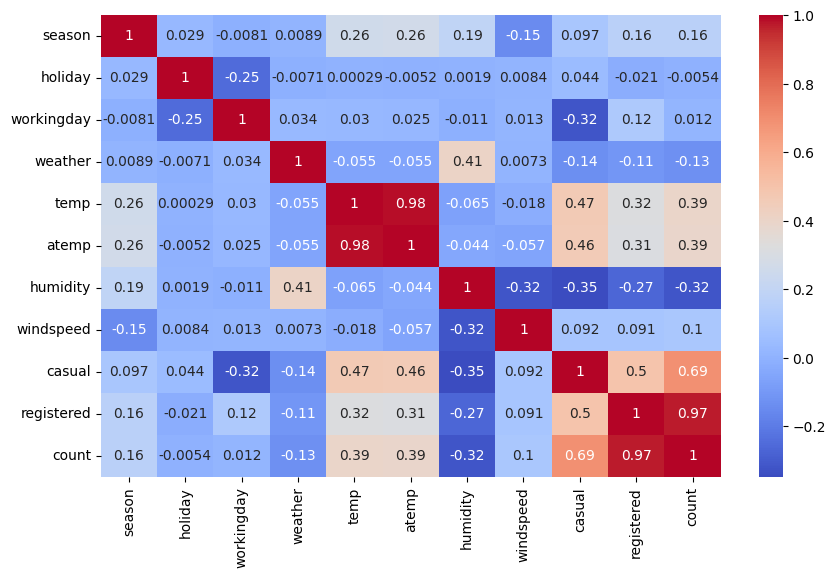

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(train.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

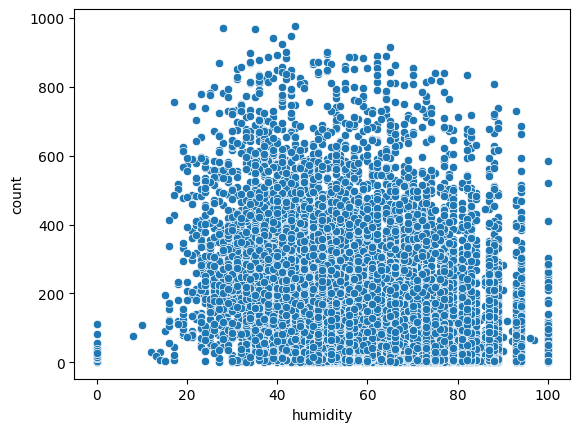

In [12]:
sns.scatterplot(
    x='humidity',
    y='count',
    data=train
)
plt.show()

In [21]:
print(train.columns)

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count', 'year',
       'month', 'day', 'hour', 'weekday'],
      dtype='object')


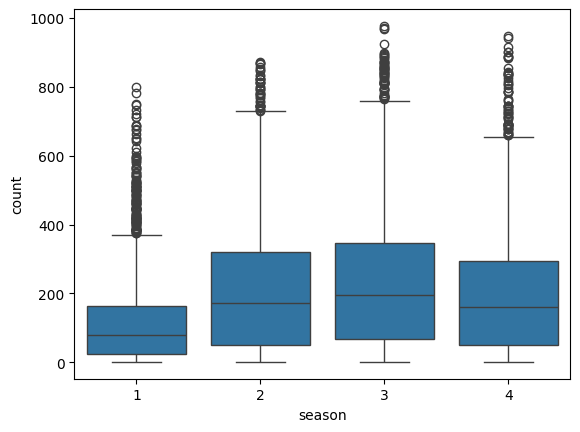

In [13]:
sns.boxplot(
    x='season',
    y='count',
    data=train
)
plt.show()

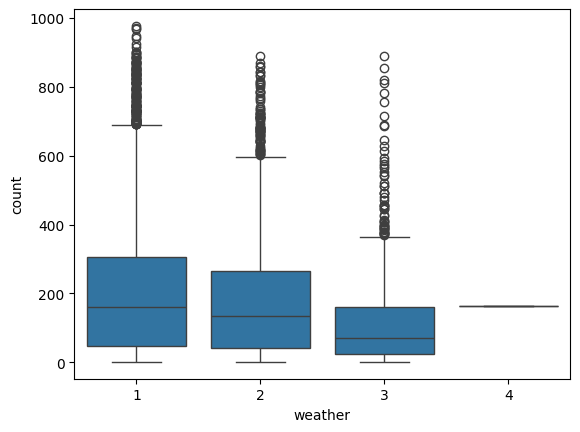

In [14]:
sns.boxplot(
    x='weather',
    y='count',
    data=train
)
plt.show()

In [25]:
X = train.drop(
    ["count","casual","registered"],
    axis=1
)

y = train["count"]

In [28]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [29]:
print(train.head())
print(train.shape)

              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  
(10886, 12)


In [30]:
X = train.drop(
    ["count","casual","registered"],
    axis=1
)

y = train["count"]

print(X.shape)
print(y.shape)

(10886, 9)
(10886,)


In [34]:
print(X.columns)

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed'],
      dtype='object')


In [40]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
lr = LinearRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_valid)

score_lr = rmsle(y_valid,pred_lr)

print(score_lr)

1.4305370124511005


In [42]:
poly2 = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('lr', LinearRegression())
])

poly2.fit(X_train,y_train)

pred_poly2 = poly2.predict(X_valid)

score_poly2 = rmsle(
    y_valid,
    pred_poly2
)

print(score_poly2)

1.3587952737834395


In [43]:
alphas = [0.001,0.01,0.1,1,10]

for a in alphas:

    model = Ridge(alpha=a)

    model.fit(X_train,y_train)

    pred = model.predict(X_valid)

    print(a, rmsle(y_valid,pred))

0.001 1.4305370136665667
0.01 1.4305370246057794
0.1 1.4305371339995254
1 1.4305382280971406
10 1.430549183168411


In [45]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

ridge = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('ridge', Ridge(alpha=1))
])

ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_valid)

In [46]:
print(pred_ridge[:5])

[276.41139049 -31.72670095 167.51580555 269.05139435 268.5808005 ]


In [49]:
residuals = y_valid - pred_ridge

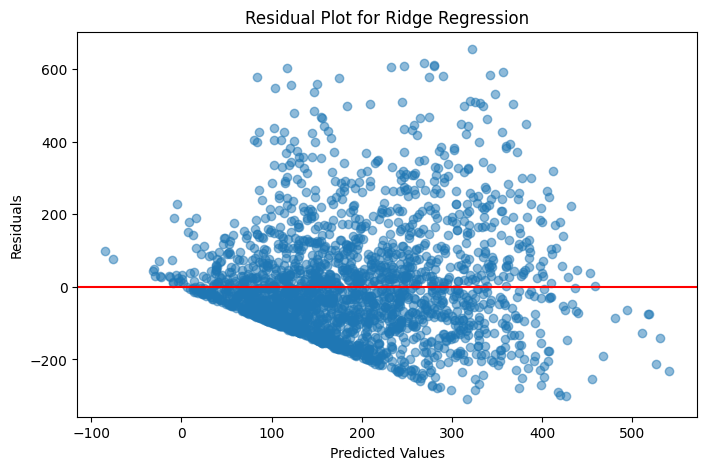

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    pred_ridge,
    residuals,
    alpha=0.5
)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot for Ridge Regression")

plt.show()

In [55]:
print("X columns:")
print(X.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

X columns:
['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']

Test columns:
['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']


In [57]:
# Only if datetime exists
if 'datetime' in test.columns:

    test['datetime'] = pd.to_datetime(test['datetime'])

    test['year'] = test['datetime'].dt.year
    test['month'] = test['datetime'].dt.month
    test['day'] = test['datetime'].dt.day
    test['hour'] = test['datetime'].dt.hour
    test['weekday'] = test['datetime'].dt.weekday

    test.drop('datetime', axis=1, inplace=True)

In [59]:
test = test[X.columns]

In [60]:
print(X.columns.tolist())
print(test.columns.tolist())

['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']
['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']


In [61]:
best_model.fit(X, y)

test_predictions = best_model.predict(test)

In [62]:
submission = pd.read_csv("sampleSubmission.csv")

submission["count"] = np.maximum(0, test_predictions)

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully")

submission.csv created successfully
